In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pathlib import Path
import json
import pandas as pd


from src.get_data_4 import get_points
from src.dip_model_adaptative import run_dip_partial_boundary


DATA_PATH = Path("./datos_sqr-4/")
RESULTS_PATH = Path("results")
RESULTS_PATH.mkdir(exist_ok=True)


# n = 128 # Tamaño de grilla
iters = 200 # Iteraciones de entrenamiento
lr = 1e-3 # Tasa de aprendizaje

/home/andres/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-11-14 16:39:24.962875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763149164.976368  102305 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763149164.980468  102305 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763149164.990725  102305 computation_placer.cc:17

In [2]:
def build_mask_and_boundary(coords, values, n, m):
    mask = np.zeros((n, m), dtype=np.float32)
    boundary = np.zeros((n, m), dtype=np.float32)
    for (x, y), v in zip(coords, values):
        # if 0 <= x < n and 0 <= y < n:
        mask[x, y] = 1.0
        boundary[x, y] = v
    return mask, boundary


def save_matrix(matrix, path):
    path = Path(path)
    if path.suffix == ".csv":
        np.savetxt(path, matrix, delimiter=",")
    else:
        np.save(path, matrix)

>> Cargando datos SOC ...
Matriz cheap: (128, 128)
N° de puntos Monte Carlo conocidos: 25


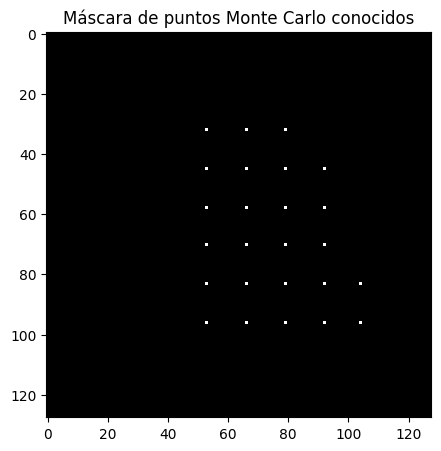

In [3]:
print(">> Cargando datos SOC ...")
coords, soc, params = get_points(DATA_PATH)
# cheap = np.loadtxt("SOC_matrix_g-4.csv", delimiter=",")
df = pd.read_csv("SOC_matrix_g-4.csv", header=None)  # usa la primera columna como índice
SOC_matrix = df.values
n, m = SOC_matrix.shape
cheap = SOC_matrix.copy()

print(f"Matriz cheap: {cheap.shape}")
print(f"N° de puntos Monte Carlo conocidos: {len(coords)}")


# === Celda 4: Construcción de máscara y frontera ===
mask, boundary = build_mask_and_boundary(coords, soc, n, m)
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="gray")
plt.title("Máscara de puntos Monte Carlo conocidos")
plt.show()

In [4]:
pts = np.array(params)

In [9]:
print(">> Iniciando entrenamiento DIP ...")
recon, hist = run_dip_partial_boundary(
cheap=cheap,
boundary=boundary,
mask=mask,
noise_shape=(32, 32, 16),
iters=200,
lr=1e-3,
weight_cheap_inside=0.1,
weight_tv=1e-4,
print_every=200,
patience=800
)
print("✅ Entrenamiento completado.")

>> Iniciando entrenamiento DIP ...
it 00001 | loss=3.077202e-01 | bnd=2.809580e-01 cheap=2.689471e-01 tv=1.941949e-02 | w_cheap=9.950e-02
it 00200 | loss=3.482834e-05 | bnd=3.214262e-05 cheap=1.810578e-02 tv=2.685718e-02 | w_cheap=0.000e+00
✅ Entrenamiento completado.


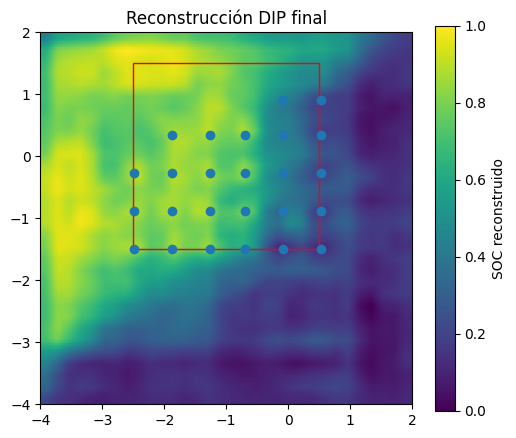

In [10]:
# save_matrix(recon, RESULTS_PATH / "recon_matrix.npy")
# with open(RESULTS_PATH / "history.json", "w") as f:
#     json.dump(hist, f)
#     print("Resultados guardados en 'results/'")

extent = [-4, 2, -4, 2]
x0, y0 = -2.5, -1.5    
lado = 3
# === Celda 7: Visualización de resultados ===

recon_rot = np.rot90(recon, k=1)  
cheap_rot = np.rot90(cheap, k=1)

plt.figure(figsize=(6, 5))
plt.imshow(recon_rot, cmap="viridis", extent=extent)

# Rectángulo en coordenadas físicas
rect = patches.Rectangle(
    (x0, y0), lado, lado,
    linewidth=1, edgecolor='red', facecolor='none'
)
plt.gca().add_patch(rect)
plt.scatter(pts[:,0], pts[:,1])
plt.colorbar(label="SOC reconstruido")
plt.title("Reconstrucción DIP final")
plt.show()

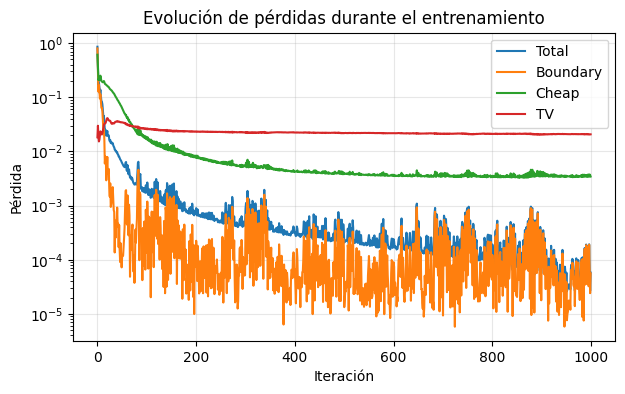

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(hist["loss_total"], label="Total")
plt.plot(hist["loss_boundary"], label="Boundary")
plt.plot(hist["loss_cheap"], label="Cheap")
plt.plot(hist["loss_tv"], label="TV")
plt.yscale("log")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Evolución de pérdidas durante el entrenamiento")
plt.show()

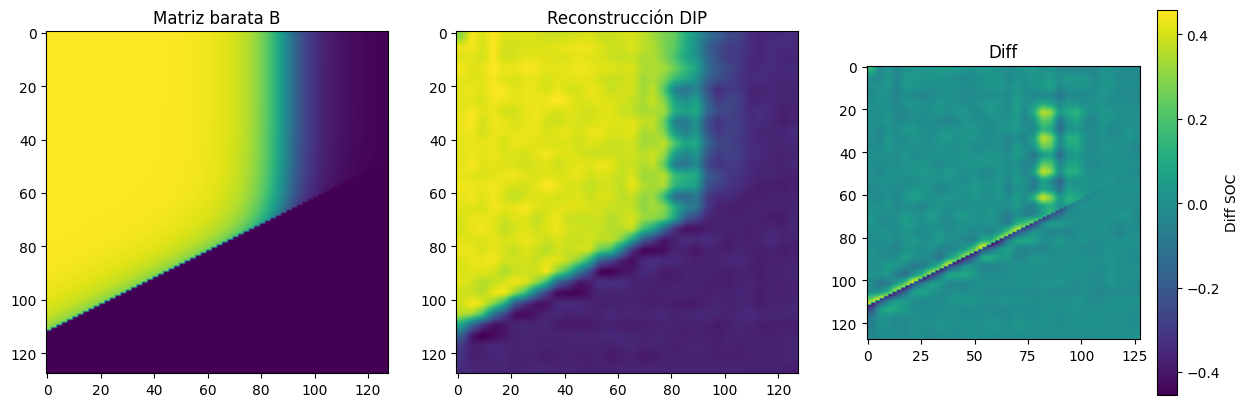

In [8]:
# MC_true = np.loadtxt("data/MC_true.csv", delimiter=",")

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cheap_rot, cmap='viridis')
plt.title("Matriz barata B")

plt.subplot(1,3,2)
plt.imshow(recon_rot, cmap='viridis')
plt.title("Reconstrucción DIP")

plt.subplot(1,3,3)
plt.imshow(cheap_rot-recon_rot, cmap='viridis')
plt.title("Diff")
plt.colorbar(label="Diff SOC")

plt.show()

# rmse = np.sqrt(np.mean((recon - MC_true)**2))
# print(f"RMSE total = {rmse:.3e}")
